In [1]:
import matplotlib.pyplot as plt
import numpy as np
from MarketSim import Market, LMSR, CFMM

LMSR Mean: -5.497990543388413
LMSR Std: 18.681077987245022
CFMM Mean: -2.9645887631375523
CFMM Std: 12.487571451896423


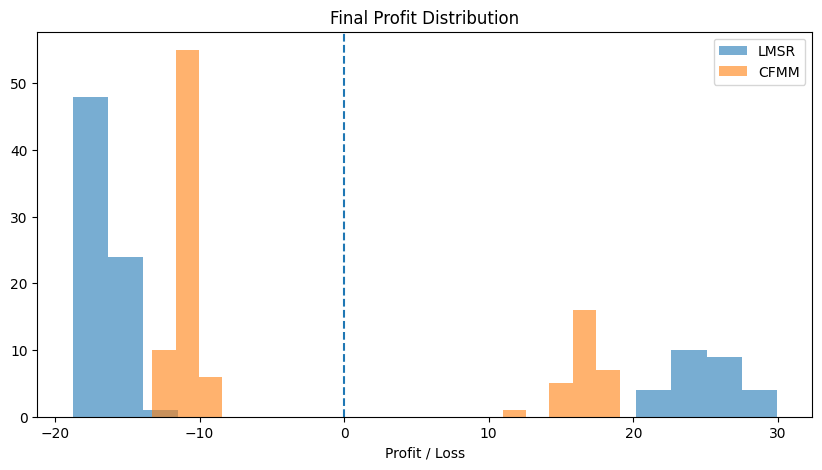

In [ ]:
np.random.seed(42)

N_RUNS = 100
T = 1000
true_p = np.array([0.3, 0.7])
noise_ratio = 0.9

lmsr_b = 50
cfmm_k = lmsr_b ** 2

profits_lmsr = []
profits_cfmm = []

for _ in range(N_RUNS):

    lmsr = LMSR(n=2, b=lmsr_b)
    cfmm = CFMM(n=2, k_constant=cfmm_k)

    m1 = Market(lmsr, T, true_p, noise_ratio)
    m2 = Market(cfmm, T, true_p, noise_ratio)

    _, _, _, r1 = m1.run()
    _, _, _, r2 = m2.run()

    profits_lmsr.append(r1)
    profits_cfmm.append(r2)


# =========================
# STATS
# =========================

print("LMSR Mean:", np.mean(profits_lmsr))
print("LMSR Std:", np.std(profits_lmsr))

print("CFMM Mean:", np.mean(profits_cfmm))
print("CFMM Std:", np.std(profits_cfmm))


# =========================
# PLOTS
# =========================

plt.figure(figsize=(10, 5))

plt.hist(profits_lmsr, bins=20, alpha=0.6, label="LMSR")
plt.hist(profits_cfmm, bins=20, alpha=0.6, label="CFMM")

plt.axvline(0, linestyle='--')
plt.title("Final Profit Distribution")
plt.xlabel("Profit / Loss")
plt.legend()
plt.show()